## Derm1M dataset

In [75]:
import io
import os
import zipfile
from PIL import Image
from huggingface_hub import HfFileSystem

# Initialize the file system 
fs = HfFileSystem()

pubmed_filenames = [
    "98_6c_PMC5383004_pone.0172624.g006_3.jpg",
    "00_39_PMC10381143_jimaging-09-00148-g011_1.jpg",
    "0d_59_PMC4458964_IJD_60_321e_g003_0.png",
    "e2_67_PMC3445843_1471_5945_12_7_7.png",
    "89_38_PMC3350198_CRIM.PEDIATRICS2012_152602.002_1.png",
    "0b_33_PMC3804142_CRIM.DENTISTRY2013_672383.001_0.png"
]

IIYI_filenames = [
    "2281_1.png",
    "14083_1.png",
]

youtube_filenames = [
    "OzBKmWt9zWo_frame_8071_0_0.jpg"
]


repo_id = "datasets/redlessone/Derm1M"
downloaded_images = {}

print("Fetching individual images via streamed remote zipfile...")

download_tasks = {
    "pubmed": pubmed_filenames,
    "IIYI": IIYI_filenames,
    "youtube": youtube_filenames
}

for category, filenames in download_tasks.items():
    zip_name = f"{category}.zip"
    remote_zip_path = f"{repo_id}/{zip_name}"
    
    try:
        with fs.open(remote_zip_path, "rb") as remote_file:
            with zipfile.ZipFile(remote_file) as zf:
                
                for filename in filenames:
                    internal_path = f"{filename}"
                    
                    try:
                        with zf.open(internal_path) as img_file:
                            img = Image.open(io.BytesIO(img_file.read())).convert("RGB")
                            
                            downloaded_images[filename] = img
                            
                            local_save_path = f"derm_train_images/{category}/{filename}"
                            os.makedirs(os.path.dirname(local_save_path), exist_ok=True)
                            img.save(local_save_path)
                            
                            print(f"[SUCCESS] Downloaded: {filename} to {local_save_path}")
                            
                    except KeyError:
                        print(f"[ERROR] File '{internal_path}' does not exist inside '{zip_name}'.")
                    except Exception as e:
                        print(f"[ERROR] Failed to download {internal_path}: {e}")
                        
    except Exception as e:
        print(f"[ERROR] Could not open remote zip '{remote_zip_path}': {e}")

if downloaded_images:
    first_image = list(downloaded_images.values())[0]
    display(first_image)

Fetching individual images via streamed remote zipfile...
[ERROR] Could not open remote zip 'datasets/redlessone/Derm1M/pubmed.zip': File is not a zip file
[ERROR] Could not open remote zip 'datasets/redlessone/Derm1M/IIYI.zip': File is not a zip file
[ERROR] Could not open remote zip 'datasets/redlessone/Derm1M/youtube.zip': File is not a zip file


In [76]:
import os
from datasets import load_dataset

# 1. Load the dataset in streaming mode (bypasses full download)
ds = load_dataset("marmal88/skin_cancer", streaming=True)
split_name = 'train' if 'train' in ds else list(ds.keys())[0]
data_stream = ds[split_name]

# 2. Extract and print all labels from the dataset features (metadata is loaded immediately)
print("=== Dataset Labels ===")
label_col_name = None

for col_name, feature in data_stream.features.items():
    if getattr(feature, 'names', None) is not None:
        print(f"Labels found in the '{col_name}' column:")
        print(feature.names)
        label_col_name = col_name
        break

if not label_col_name:
    # Fallback to look for common text label columns if ClassLabel isn't used
    for fallback_col in ['dx', 'label', 'cell_type', 'diagnosis']:
        if fallback_col in data_stream.features:
            print(f"Dataset contains a label column named: '{fallback_col}'")
            label_col_name = fallback_col
            break

# 3. Create the directory for the images
output_dir = "ham_images" 
os.makedirs(output_dir, exist_ok=True)

# 4. Stream, shuffle, and take 5 images
print(f"\n=== Saving 5 Random Images to {output_dir}/ ===")

# shuffle() with a buffer loads 'buffer_size' elements into memory and samples from them
sampled_stream = data_stream.shuffle(buffer_size=1000, seed=1).take(5)

for i, sample in enumerate(sampled_stream):
    if 'image' in sample:
        img = sample['image']
        
        # Get label value
        label_val = sample.get(label_col_name, "unknown") if label_col_name else "unknown"
        
        # If it's a ClassLabel integer, map it back to the string name
        if isinstance(label_val, int) and label_col_name and hasattr(data_stream.features[label_col_name], 'names'):
            label_val = data_stream.features[label_col_name].names[label_val]
            
        # Clean label string for valid filename
        safe_label = str(label_val).replace(" ", "_").replace("/", "-")
        
        filename = f"sample_{i}_{safe_label}.jpg"
        save_path = os.path.join(output_dir, filename)
        
        # Save RGB image
        img.convert("RGB").save(save_path)
        print(f"Saved: {save_path}")
    else:
        print("Error: Could not find an 'image' column in the sample.")

c:\Users\asiaa\OneDrive\Desktop\Studia\Sezon 7\XAI\derm-overview\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\asiaa\.cache\huggingface\hub\datasets--marmal88--skin_cancer. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


=== Dataset Labels ===
Dataset contains a label column named: 'dx'

=== Saving 5 Random Images to ham_images/ ===
Saved: ham_images\sample_0_melanocytic_Nevi.jpg
Saved: ham_images\sample_1_melanocytic_Nevi.jpg
Saved: ham_images\sample_2_melanoma.jpg
Saved: ham_images\sample_3_melanoma.jpg
Saved: ham_images\sample_4_melanocytic_Nevi.jpg


In [ ]:
import open_clip

# List all available models and pretraining datasets
available_models = open_clip.list_models()
print([m for m in available_models if 'coca' in m.lower()])

# For a specific model, check available pretrained weights
pretrained_options = open_clip.list_pretrained('coca_ViT-B-32')
print(pretrained_options)

# Downloading additional datasets

In [4]:
!pip install remotezip

In [3]:
sample_number = 2 # musi się dzielić przez 5!!!

In [5]:
from remotezip import RemoteZip
from sympy import content
import os
from pathlib import Path
import random

def download_imgs (url, dir_name, samples_no, forbidden=[]):
    directory = Path(dir_name) 
    paths = []
    with RemoteZip(url) as z:
        files = [f for f in z.namelist() if not f.endswith("/")]
        files = [
            f for f in files
            if not any(os.path.basename(f).startswith(prefix) for prefix in forbidden)
        ]

        sample_size = min(samples_no, len(files))
        random_files = random.sample(files, sample_size)

        for path in random_files:
            paths.append(path)
            dest = directory / os.path.basename(path)
            dest.parent.mkdir(parents=True, exist_ok=True)
            with z.open(path) as src, open(dest, "wb") as dst:
                dst.write(src.read())
                print(f"Downloaded {path} to {dest}")
                
    return paths
    



## PAD dataset

In [6]:
directory = "pad_images"

In [7]:
url = "https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/4ea8d71a-260e-4f97-a977-2c426ae6d4a4"
_ = download_imgs(url, directory, sample_number)

Downloaded imgs_part_1/PAT_378_769_36.png to pad_images/PAT_378_769_36.png
Downloaded imgs_part_1/PAT_53_82_657.png to pad_images/PAT_53_82_657.png


In [8]:
!curl -o "metadata.csv" "https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/de867406-1a86-4eb7-bffa-3db4ab357f3f"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  308k  100  308k    0     0   864k      0 --:--:-- --:--:-- --:--:--  864k


In [9]:
# creating meta file for imgs

import pandas as pd
import os

df = pd.read_csv("metadata.csv")

if os.path.exists(os.path.join(directory, "meta.csv")):
    os.remove(os.path.join(directory, "meta.csv"))
    
img_names = []

for img_name in os.listdir(directory):
    img_names.append(img_name)

chosen = df[df["img_id"].isin(img_names)]
chosen["filename"] = chosen["img_id"]

skin_lesions = {
    "BCC": "Basal Cell Carcinoma",
    "SCC": "Squamous Cell Carcinoma",
    "ACK": "Actinic Keratosis",
    "SEK": "Seborrheic Keratosis",
    "MEL": "Melanoma",
    "NEV": "Nevus"
}
labels = list(skin_lesions.values()) # WAZNE
chosen["label"] = chosen["diagnostic"].map(skin_lesions)
chosen = chosen[["filename", "label"]]
chosen.to_csv(os.path.join(directory, "meta.csv"), index=False) 
os.remove("metadata.csv")

In [10]:
pad_labels = [
    "Basal Cell Carcinoma",
    "Squamous Cell Carcinoma",
    "Actinic Keratosis",
    "Seborrheic Keratosis",
    "Melanoma",
    "Nevus"
]

## Daffodil International University dataset

In [50]:
directory = "daffodil_images"

In [ ]:
urls = ["https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/5aca09ba-1b5a-4564-aa2f-88b6df0ccb4f", 
        "https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/ed53b1d3-d6b4-4d8e-9704-68a57a875e0b", 
        "https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/a035eab7-4cf8-4590-8b9a-2ecf4ae315f1", 
        "https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/6b6cbf5e-47f0-4d58-af85-435ae786a0fb", 
        "https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/4e221083-4f36-4d33-90b6-c12fe5561441"]

daffodil_labels = ["acne", 
          "hyperpigmentation",
          "nail psoriasis",
          "sjs ten", 
          "vitiligo"]

all_imgs_names = []
for url, label in zip(urls, daffodil_labels):
    imgs_names = download_imgs(url, directory, sample_number/5, ['padd', 'saturation','superpixels', 'hue'])
    all_imgs_names.append(imgs_names)

Downloaded acne/Resize-450_400193__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpg to daffodil_images\Resize-450_400193__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpg
Downloaded acne/195__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpg to daffodil_images\195__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpg
Downloaded hyperpigmentation/Crop-0350_100400acquired-dermal-macular-hyperpigmentation-012__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpeg to daffodil_images\Crop-0350_100400acquired-dermal-macular-hyperpigmentation-012__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpeg
Downloaded hyperpigmentation/flip--1acquired-dermal-macular-hyperpigmentation-004__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpeg to daffodil_images\flip--1acquired-dermal-macular-hyperpigmentation-004__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpeg
Downloaded Nail_psoriasis/flip-03257__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.j

In [52]:
# creating meta file for imgs
rows = []

for label, img_names in zip(daffodil_labels, all_imgs_names):
    for name in img_names:
        rows.append({"filename": name, "label": label})

df = pd.DataFrame(rows)

df.to_csv(os.path.join(directory, "meta.csv"), index=False)

# MONET Model

In [1]:
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification

processor = AutoProcessor.from_pretrained("suinleelab/monet")
model = AutoModelForZeroShotImageClassification.from_pretrained("suinleelab/monet")

c:\Users\asiaa\OneDrive\Desktop\Studia\Sezon 7\XAI\derm-overview\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\asiaa\OneDrive\Desktop\Studia\Sezon 7\XAI\derm-overview\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\asiaa\.cache\huggingface\hub\models--suinleelab--monet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mod

                                            filename label
0  acne_144__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5...  acne
1  acne_154__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5...  acne
2  acne_171__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5...  acne
3  acne_182__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5...  acne
4  acne_193__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5...  acne


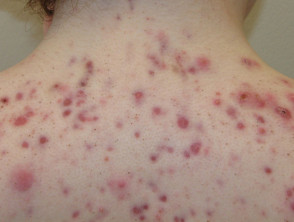

Label: acne


In [10]:
import pandas as pd
import os
from PIL import Image
directory = "daffodil_images"

meta = pd.read_csv(os.path.join(directory, "meta.csv"))
print(meta.head())
img_path = os.path.join(directory, meta.iloc[0]['filename'])
img = Image.open(img_path).convert("RGB")
label = meta.iloc[0]['label']
display(img)
print(f"Label: {label}")

In [ ]:
import torch
model.eval()

daffodil_labels = [
    "acne",
    "hyperpigmentation",
    "nail psoriasis",
    "sjs ten", 
    "vitiligo"
]

inputs = processor(
    images=img,
    text=daffodil_labels,
    return_tensors="pt",
    padding=True
)

with torch.no_grad():
    outputs = model(**inputs)
    

print(outputs)

CLIPOutput(loss=None, logits_per_image=tensor([[32.2339, 26.9494, 22.2684, 28.8214, 25.1216]]), logits_per_text=tensor([[32.2339],
        [26.9494],
        [22.2684],
        [28.8214],
        [25.1216]]), text_embeds=tensor([[-0.0086,  0.0340,  0.0150,  ..., -0.0060, -0.0012, -0.0220],
        [-0.0361,  0.0591, -0.0020,  ..., -0.0264,  0.0207,  0.0243],
        [-0.0109,  0.0202, -0.0269,  ...,  0.0124,  0.0334, -0.0113],
        [-0.0005,  0.0548, -0.0418,  ..., -0.0014, -0.0029, -0.0352],
        [ 0.0051,  0.0537, -0.0030,  ..., -0.0026,  0.0101,  0.0102]]), image_embeds=tensor([[ 1.5615e-02,  9.1781e-02,  2.4979e-02,  3.1453e-02, -1.5696e-02,
         -2.1619e-02, -1.0667e-02,  6.3974e-02,  1.6011e-02, -4.9491e-02,
          1.1850e-02, -2.4691e-02, -1.7824e-02,  3.1296e-02,  2.8528e-02,
         -1.4453e-02,  1.1595e-02, -8.1918e-06, -3.9903e-03, -1.8816e-02,
          2.9818e-02, -2.2254e-02, -1.3955e-02, -7.4584e-03, -2.5396e-02,
          2.3753e-02,  5.4568e-02,  7.1579e-